<a href="https://colab.research.google.com/github/Rekhakumari28/AI-ML-MiniProjects/blob/AI_ML_Week4_Project_Unsupervised_Learning_%26_Model_Tuning/AI_ML_Week4_Project_Unsupervised_Learning_%26_Model_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Segmentation using Unsupervised Learning**


**Presented By** : Rekha Kumari Bheel

**GitHub Link** : [Link]("")

**Tech Stack / Tools & Libraries** :

* Python

* Scikit-learn → clustering, PCA, evaluation metrics

* Matplotlib, Seaborn → visualization

* Pandas, NumPy → data preprocessing

**Domain** : E-Commerce

**Data Type**:

* Customer Purchase Data

* RFM Variables (Recency, Frequency, Monetary)



## **Unsupervised Learning (Theory)**

### **Definition**

Unsupervised Learning is a type of machine learning where models are trained on unlabeled data.

* The algorithm tries to discover hidden patterns, structures, or groupings in the dataset without predefined outputs (labels).

* It focuses on understanding the intrinsic structure of data rather than predicting outcomes.

### **Key Characteristics**

1. **No Labels Provided** → only input features are available.

2. **Pattern Discovery** → the goal is to group or represent data efficiently.

3. **Exploratory Analysis** → often used to gain insights when little prior knowledge exists.

4. **Evaluation is Challenging** → since ground truth labels are missing, performance is often measured with internal metrics (e.g., Silhouette Score, Davies-Bouldin Index).

### **Techniques**

1. **Clustering** → Grouping similar data points

   * Examples: K-Means, Hierarchical, DBSCAN

2. **Dimensionality Reduction** → Compressing data while retaining key info

    * Examples: PCA, t-SNE, Autoencoders

3. **Association Rule Learning** → Discovering rules & correlations

    * Example: Market basket analysis (bread → butter)        

## **Clustering (K-Means)**

### **Definition**

**K-Means Clustering** is an **unsupervised learning algorithm** that divides data into **K clusters** by minimizing **intra-cluster variance (within-cluster sum of squares, WCSS)**.

* Each cluster is represented by its **centroid** (mean of data points).

* The algorithm tries to place points in the cluster whose centroid is closest.

## **Algorithm Steps**

1. Choose the number of clusters K.

2. Initialize K centroids randomly.

3. Assign each data point to the nearest centroid.

4. Update centroids as the mean of assigned points.

5. Repeat steps 3–4 until centroids don’t change (convergence).

## **Key Formula**

Minimize the objective function:

## J = Σ (i=1 to K) Σ (x ∈ Ci) ||x - μi||²

Where:
* Ci = set of points in cluster i
* μi = centroid of cluster i

**Advantages**

* Simple & fast.

* Works well for spherical clusters.

* Scales to large datasets.

**Limitations**

* Requires predefining K.

* Sensitive to outliers.

* Assumes clusters are spherical and equal size.

Cluster labels (first 10): [1 1 1 1 1 1 1 1 1 1]


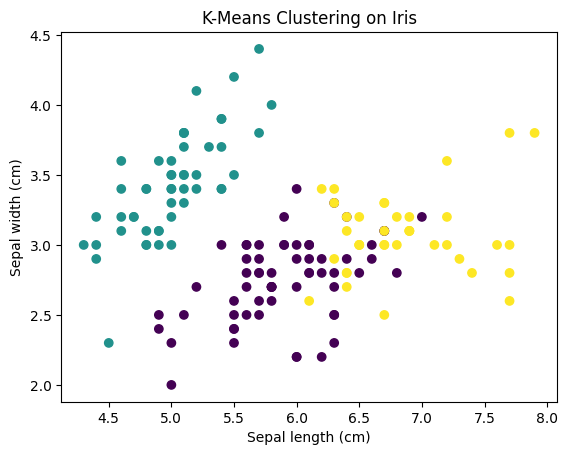

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

# Load dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

print("Cluster labels (first 10):", clusters[:10])

# Plot clusters
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=clusters, cmap='viridis')
plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.title("K-Means Clustering on Iris")
plt.show()


## **Clustering (Hierarchical)**

### **Definition**

**Hierarchical Clustering** is an **unsupervised learning technique** that builds **nested cluster**s by either:

* **Agglomerative (bottom-up)** → start with each data point as its own cluster, then merge them step by step.

* **Divisive (top-down)** → start with one big cluster, then split it recursively.

### **How It Works (Agglomerative - most common)**

1. Start with N clusters (each data point = one cluster).

2. Compute the distance between all clusters.

3. Merge the two closest clusters.

4. Recompute distances.

5. Repeat until only one cluster remains → represented as a dendrogram.

### **Linkage Methods**

* **Single Linkage** → minimum distance between points.

* **Complete Linkage** → maximum distance between points.

* **Average Linkage** → average distance between points.

* **Ward’s Method** → minimizes variance within clusters.

### **Advantages**

* Produces a dendrogram (tree-like diagram) that shows clustering structure at all levels.

* No need to pre-specify number of clusters (you can cut dendrogram at desired level).

### **Limitations**

* Computationally expensive for large datasets.

* Sensitive to noise & outliers.

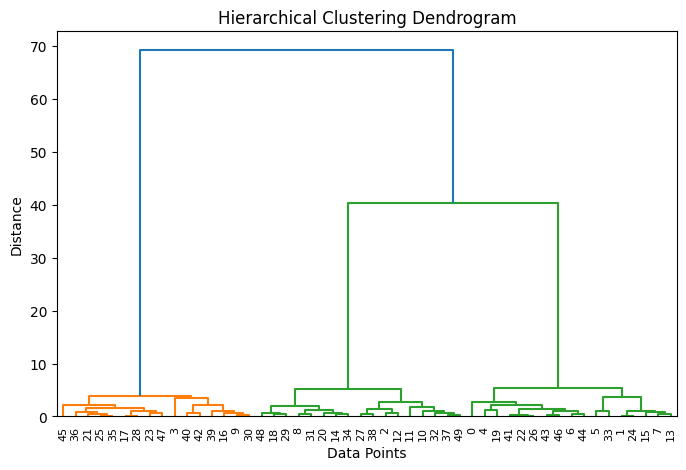

[3 3 2 1 3 3 3 3 2 1]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Generate sample data
X, _ = make_blobs(n_samples=50, centers=3, random_state=42)

# Perform hierarchical clustering
Z = linkage(X, method='ward')

# Plot dendrogram
plt.figure(figsize=(8, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

# Cut the dendrogram at 3 clusters
clusters = fcluster(Z, t=3, criterion="maxclust")
print(clusters[:10])  # First 10 cluster labels


## **PCA (Principal Component Analysis)**

###  **Definition**

**Principal Component Analysis (PCA)** is a **dimensionality reduction technique** that transforms data into a new coordinate system such that:

* The first principal component captures the maximum variance.

* The second principal component captures the next highest variance, orthogonal to the first.

* And so on…

 It reduces the number of features while retaining most of the variance (information) in the data.

### **Key Steps**

1. Standardize the data.

2. Compute the covariance matrix.

3. Calculate eigenvectors (directions) & eigenvalues (variance explained).

4. Select top k components (based on explained variance).

5. Transform data into the new k-dimensional space.

###  **Formula**

Maximize the variance projection:

## Z=X⋅W

Where:

X = standardized data

W = matrix of eigenvectors (principal components)

Z = transformed data (principal components)

### **Advantages**

* Reduces dimensionality → faster training.

* Removes multicollinearity.

* Helps with visualization in 2D/3D.

### **Limitations**

* Principal components may be hard to interpret.

* Assumes linear relationships.

* Sensitive to scaling.

Explained variance ratio: [0.72962445 0.22850762]


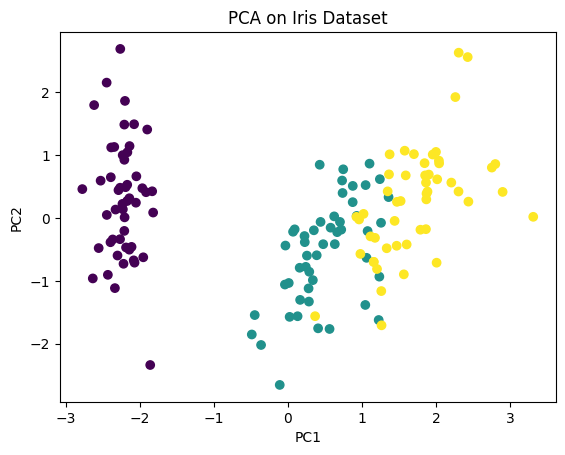

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA (2 components for visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

# Plot PCA result
plt.scatter(X_pca[:,0], X_pca[:,1], c=iris.target, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA on Iris Dataset")
plt.show()


## **t-SNE (t-Distributed Stochastic Neighbor Embedding)**

### **Definition**

* t-SNE is a non-linear dimensionality reduction technique.

* It is mainly used for visualizing high-dimensional data in 2D or 3D.

* Unlike PCA, it focuses on preserving the local structure (neighborhoods of points).

### **Key Points**

* Preserves local similarity between data points.

* Useful for exploring clusters in data (like images, text embeddings, gene data).

* Not good for very large datasets (computationally heavy).



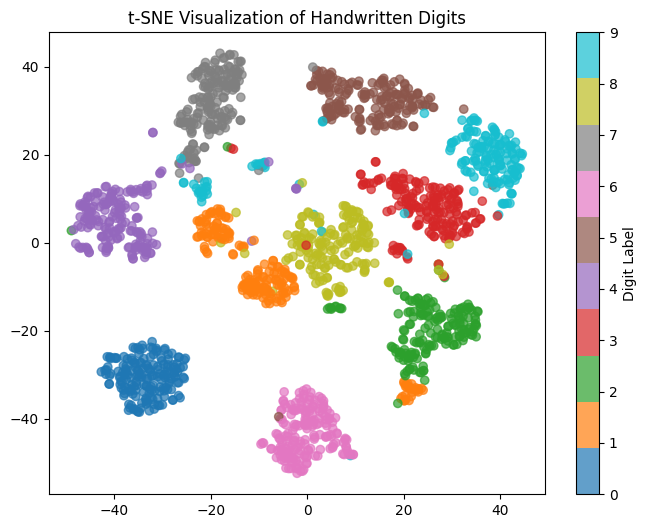

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Load sample dataset (Handwritten digits: 64 features)
digits = load_digits()
X, y = digits.data, digits.target

# Standardize data
X_scaled = StandardScaler().fit_transform(X)

# Apply t-SNE (reduce to 2D)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# Plot the 2D visualization
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap="tab10", alpha=0.7)
plt.colorbar(scatter, label="Digit Label")
plt.title("t-SNE Visualization of Handwritten Digits")
plt.show()


### **Output**
* Each point = one handwritten digit (0–9).

* Points with the same label cluster close together.

* Easy to see natural groupings in complex data.

## **GridSearchCV**

### **Definition**

* **GridSearchCV** is a technique in **model tuning**.

* It performs an exhaustive search over a given set of hyperparameters.

* Uses cross-validation (CV) to evaluate performance for each parameter combination.

* Returns the best parameters and the best model.

### **Steps**

1. Define a model.

2. Create a dictionary of hyperparameters to test.

3. Run GridSearchCV with cross-validation.

4. Get the best parameters and accuracy.

### **Why use GridSearchCV?**

* Automates the process of finding the best hyperparameters.

* Prevents overfitting by using cross-validation.

* Works with any ML model (SVM, Random Forest, XGBoost, etc.).

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, train_test_split

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define model
dt = DecisionTreeClassifier(random_state=42)

# Define parameter grid
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_split": [2, 3, 4]
}

# Apply GridSearchCV
grid = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)

# Results
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
print("Test Accuracy:", grid.best_estimator_.score(X_test, y_test))


Best Parameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 2}
Best CV Score: 0.9416666666666668
Test Accuracy: 1.0


## **Hyperparameter Tuning**
### **Definition**

* Hyperparameters are configuration settings chosen before training a model.

* They are not learned from the data but set manually (e.g., K in K-Means, max_depth in Decision Trees, C in SVM).

* Hyperparameter Tuning is the process of finding the best set of hyperparameters to improve model performance.

###  **Examples of Hyperparameters**

* K-Means → number of clusters (K)

* Decision Tree → max_depth, min_samples_split

* Random Forest → n_estimators, max_features

* SVM → C, kernel, gamma

* Neural Networks → learning rate, batch size, hidden layers

### **Summary**

* Hyperparameter Tuning = optimizing parameters to improve accuracy.

* Can be done using:

   * Manual Search → e.g., Elbow Method for K-Means.

   * Automated Search → GridSearchCV, RandomizedSearchCV, Bayesian Optimization.

Example 1: GridSearchCV for Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, train_test_split

# Train-test split
from sklearn.datasets import load_iris
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Hyperparameter grid
param_grid = {"max_depth": [2, 3, 4, 5, None],
              "min_samples_split": [2, 3, 4]}

# GridSearchCV
grid = GridSearchCV(dt, param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)


Best Parameters: {'max_depth': 4, 'min_samples_split': 2}
Best Accuracy: 0.9416666666666668


Example 2: Choosing K in K-Means (Elbow Method)

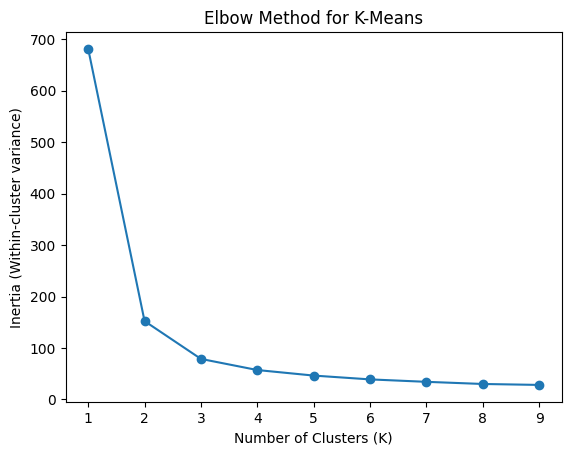

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()
X = iris.data

# Elbow method to find best K
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot Elbow curve
plt.plot(K, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-cluster variance)")
plt.title("Elbow Method for K-Means")
plt.show()
